# Seq2Seq 모델 Q&A Chatbot 구현

1. QnA 데이터셋을 찾아서 처리해서 준비한다. (전처리 전반)
2. Encoder, Decoder, Seq2Seq(Encoder+Decoder) 모델을 만든다.
3. 1에서 준비한 데이터로 2에서 만든 모델을 학습시킨다.
4. Chatbot을 만든다. (모델 추론 + while문)

### 데이터 로드

In [7]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [8]:
digital_df = pd.read_csv('/content/sbo_qun/디지털가전_train.csv', encoding='utf-8')
digital_df.info()
digital_df = digital_df[['발화자', '발화문']]

/tmp/ipykernel_1232/2020573290.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  digital_df = pd.read_csv('/content/sbo_qun/디지털가전_train.csv', encoding='utf-8')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742995 entries, 0 to 742994
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   IDX     742995 non-null  int64 
 1   발화자     742995 non-null  object
 2   발화문     742995 non-null  object
 3   카테고리    742995 non-null  object
 4   QA번호    742995 non-null  int64 
 5   QA여부    742995 non-null  object
 6   감성      742995 non-null  object
 7   인텐트     742995 non-null  object
 8   가격      14038 non-null   object
 9   수량      19132 non-null   object
 10  크기      26983 non-null   object
 11  장소      8065 non-null    object
 12  조직      27984 non-null   object
 13  사람      349 non-null     object
 14  시간      575 non-null     object
 15  날짜      45050 non-null   object
 16  상품명     272932 non-null  object
 17  상담번호    742995 non-null  int64 
 18  상담내순번   742995 non-null  int64 
dtypes: int64(4), object(15)
memory usage: 107.7+ MB


In [9]:
display(digital_df.head(100))

,발화자,발화문
0,c,아 그래요?
1,s,네 지금 이제품이 베스트 제품인데요
2,s,컬러가 들어가서 화사해서 여성분들이 많이 좋아하세요
3,s,김치냉장고 겸용말고 그냥 김치 냉장고만 찾으시는?
4,c,네 그냥 김치만 넣을수 잇는
...,...,...
95,c,그거 전부 날리셔도 됩니다
96,c,데스크탑은 뭐 급한건도 아니고요
97,s,아 그렇군요
98,c,아 제가 잘몰라서 이것 저것 물어봐요 죄송합니다


### 전처리 - 일단 정제와 묶어주기

In [10]:
import re

def clean_text(text):
    # 1. 문자가 아닌 경우(NaN 등) 빈 문자열로 처리
    if not isinstance(text, str):
        return ""

    # 2. 한글과 공백만 남기고 제거 (특수문자, 숫자 등 삭제)
    text = re.sub(r'[^가-힣\s]', '', text)

    # 3. 양끝 공백 제거
    text = text.strip()

    return text


digital_df['발화문'] = digital_df['발화문'].apply(clean_text)

# 결과 확인 (빈 문자열이 된 행이 있을 수 있으니 다시 한번 체크)
display(digital_df.head(100))

,발화자,발화문
0,c,아 그래요
1,s,네 지금 이제품이 베스트 제품인데요
2,s,컬러가 들어가서 화사해서 여성분들이 많이 좋아하세요
3,s,김치냉장고 겸용말고 그냥 김치 냉장고만 찾으시는
4,c,네 그냥 김치만 넣을수 잇는
...,...,...
95,c,그거 전부 날리셔도 됩니다
96,c,데스크탑은 뭐 급한건도 아니고요
97,s,아 그렇군요
98,c,아 제가 잘몰라서 이것 저것 물어봐요 죄송합니다


In [11]:
digital_df.head(50)

# 만개 데이터로 테스트
df_subset = digital_df.iloc[:10000]

In [12]:
def preprocess_data(df):
    question_inputs = []  # Encoder Input (C)
    answer_inputs = []    # Decoder Input (S + <sos>)
    answer_targets = []   # Decoder Target (S + <eos>)

    # 1. 연속된 발화 합치기 로직
    dialogue_turns = []
    current_speaker = None
    current_text = ""

    for _, row in df.iterrows():
        speaker = row['발화자']
        text = str(row['발화문']).strip()

        if speaker == current_speaker:
            current_text += " " + text
        else:
            if current_speaker is not None:
                dialogue_turns.append({'speaker': current_speaker, 'text': current_text})
            current_speaker = speaker
            current_text = text

    if current_text:
        dialogue_turns.append({'speaker': current_speaker, 'text': current_text})

    # 2. Q(C) - A(S) 쌍을 생성하며 특수 토큰 추가
    # 2만 건 이상의 데이터를 처리하므로 효율적인 반복문 사용
    for i in range(len(dialogue_turns) - 1):
        # 질문자(c)와 답변자(s) 쌍 확인
        if dialogue_turns[i]['speaker'] == 'c' and dialogue_turns[i+1]['speaker'] == 's':
            q_text = dialogue_turns[i]['text']
            a_text = dialogue_turns[i+1]['text']

            # Encoder Input: 질문 그대로
            question_inputs.append(q_text)

            # Decoder Input: <sos> 답변
            answer_inputs.append('<sos> ' + a_text)

            # Decoder Target: 답변 <eos>
            answer_targets.append(a_text + ' <eos>')

    return question_inputs, answer_inputs, answer_targets

# 실행 예시
# q_inp, a_inp, a_tar = prepare_seq2seq_data(df)

# 확인용
# print(f"질문 예시: {q_inp[0]}")
# print(f"디코더 입력 예시: {a_inp[0]}")
# print(f"디코더 타겟 예시: {a_tar[0]}")

In [13]:
question_inputs, answer_inputs, answer_targets = preprocess_data(digital_df)

In [14]:
print(question_inputs[:10])
print(answer_inputs[:10])
print(answer_targets[:10])

print(len(question_inputs), len(answer_inputs), len(answer_targets))

['아 그래요', '네 그냥 김치만 넣을수 잇는', '네 어디 선물 해주고 싶은데가 있어서 한번', '사는집보다 큰대로 가서 이게 마음에 드네요', '네 알겠습니다 여기 렌탈 하죠', '가전제품 맞죠', '이게 중간 이렇게 뚫려 있어서 되게 귀여운거 같아요', '아 살게 너무 많아서요 에어렙도 사고 싶고 저 드라이기도', '맞아요 소형 작은거요', '아 이게 다쳐서 안 되는구나']
['<sos> 네 지금 이제품이 베스트 제품인데요 컬러가 들어가서 화사해서 여성분들이 많이 좋아하세요 김치냉장고 겸용말고 그냥 김치 냉장고만 찾으시는', '<sos> 아 아예 미니 사이즈 말씀하시는거죠', '<sos> 인치요', '<sos> 죄송합니다 잠시만 기다려 주세요 먼저 오신 손님이 카드를 만들어야 하기 때문에 잠시만 기다려 주세요', '<sos> 네네', '<sos> 네네', '<sos> 예 맞아요', '<sos> 네 맞아요 저도 에어랩하고 그거랑 둘 중에 하나가 고민돼요', '<sos> 네 여기 가지 있습니다', '<sos> 네 그래요']
['네 지금 이제품이 베스트 제품인데요 컬러가 들어가서 화사해서 여성분들이 많이 좋아하세요 김치냉장고 겸용말고 그냥 김치 냉장고만 찾으시는 <eos>', '아 아예 미니 사이즈 말씀하시는거죠 <eos>', '인치요 <eos>', '죄송합니다 잠시만 기다려 주세요 먼저 오신 손님이 카드를 만들어야 하기 때문에 잠시만 기다려 주세요 <eos>', '네네 <eos>', '네네 <eos>', '예 맞아요 <eos>', '네 맞아요 저도 에어랩하고 그거랑 둘 중에 하나가 고민돼요 <eos>', '네 여기 가지 있습니다 <eos>', '네 그래요 <eos>']
320524 320524 320524


### 전역변수 선언

- 배치 크기, 단어사전 크기, 임베딩 차원, 뉴런수

In [15]:
BATCH_SIZE = 64
MAX_VOCAB_SIZE = 10000
EMBEDDING_DIM = 100
LATENT_DIM = 512

In [16]:
all_texts = question_inputs + answer_inputs + answer_targets

# 같은 한국어이므로 하나의 토크나이저로 모든 텍스트 학습
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters=' ')
tokenizer.fit_on_texts(all_texts)

# 변환
question_seqs = tokenizer.texts_to_sequences(question_inputs)
answer_input_seqs = tokenizer.texts_to_sequences(answer_inputs)
answer_target_seqs = tokenizer.texts_to_sequences(answer_targets)

num_words = len(tokenizer.word_index) + 1
max_len = max(max(len(s) for s in answer_input_seqs), max(len(s) for s in answer_input_seqs))

print(f'{num_words = }')
print(f'{max_len = }')

num_words = 347555
max_len = 147


In [17]:
encoder_inputs = pad_sequences(question_seqs, maxlen=max_len, padding='pre')
decoder_inputs = pad_sequences(answer_input_seqs, maxlen=max_len, padding='post')
decoder_targets = pad_sequences(answer_target_seqs, maxlen=max_len, padding='post')

print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

print(encoder_inputs[1000])
print([tokenizer.index_word[s] for s in encoder_inputs[1000] if s != 0])
print(decoder_inputs[1000])
print([tokenizer.index_word[s] for s in decoder_inputs[1000] if s != 0])
print(decoder_targets[1000])
print([tokenizer.index_word[s] for s in decoder_targets[1000] if s != 0])

(320524, 147)
(320524, 147)
(320524, 147)
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0  921  336  829 4212  356  615]
['그래요', '그냥', '프린터', '정도만', '하면', '되는데']
[1 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0

### 데이터셋 준비

In [18]:
class MMTDAtaset(Dataset):
  def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
    super().__init__()
    self.encoder_inputs = encoder_inputs
    self.decoder_inputs = decoder_inputs
    self.decoder_targets = decoder_targets

  def __len__(self):
    return len(self.encoder_inputs) # 3개의 길이는 똑같으니 아무거나

  def __getitem__(self, index):
    return(
        torch.tensor(self.encoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_targets[index], dtype=torch.long)
    )

In [19]:
train_index, val_index = train_test_split(range(len(encoder_inputs)), random_state=0)
print(len(train_index), len(val_index))

train_dataset = MMTDAtaset(
    encoder_inputs[train_index],
    decoder_inputs[train_index],
    decoder_targets[train_index]
)
val_dataset = MMTDAtaset(
    encoder_inputs[val_index],
    decoder_inputs[val_index],
    decoder_targets[val_index]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

240393 80131


### Seq2Seq Model

In [20]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)

    def forward(self, X):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X)
        return h_s, c_s

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
        self.fc = nn.Linear(latent_dim, vocab_size)

    def forward(self, X, hidden, cell):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X, (hidden, cell))
        logits = self.fc(output)
        return logits, h_s, c_s

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target):
        h_s, c_s = self.encoder(source)
        output, h_s, c_s = self.decoder(target, h_s, c_s)
        return output

In [21]:
encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder)

In [22]:
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(347555, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(347555, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=347555, bias=True)
  )
)

In [24]:
# !pip install torchviz graphviz

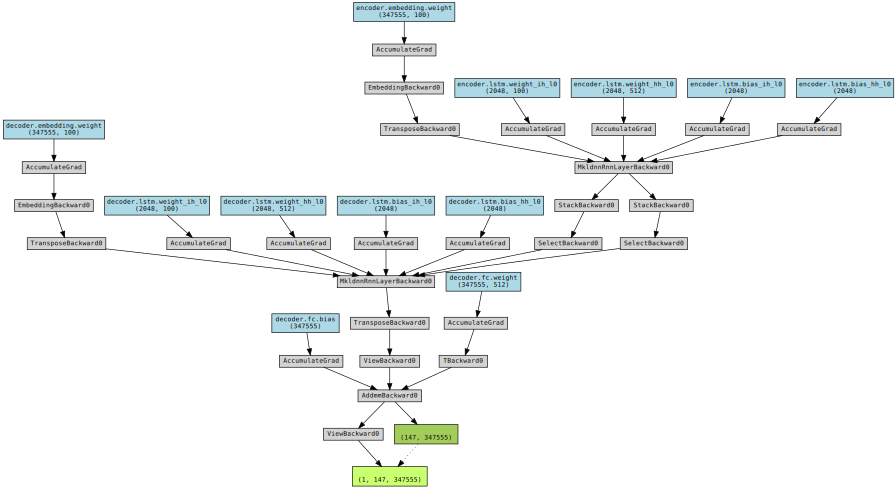

In [25]:
from torchviz import make_dot

source_input = torch.randint(0, num_words, (1, max_len))
target_input = torch.randint(0, num_words, (1, max_len))

out = model(source_input, target_input)

make_dot(out, params=dict(list(model.named_parameters())))
make_dot(out, params=dict(list(model.named_parameters())))

### 모델 학습

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)
model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 100

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(epochs):
  model.train()
  train_loss, train_correct, train_tokens = 0, 0, 0

  for enc_inputs, dec_inputs, dec_targets in train_loader:
    enc_inputs = enc_inputs.to(device)
    dec_inputs = dec_inputs.to(device)
    dec_targets = dec_targets.to(device)

    optimizer.zero_grad()

    # teacher forcing
    output = model(enc_inputs, dec_inputs)
    output = output.view(-1, output.size(-1))
    dec_targets = dec_targets.view(-1)

    loss = criterion(output, dec_targets)
    loss.backward()
    optimizer.step()

    preds = output.argmax(dim=-1)
    train_loss += loss.detach().cpu().item()
    mask = dec_targets != 0
    correct = (preds == dec_targets) & mask
    train_correct += correct.sum().detach().cpu().item()
    train_tokens += mask.sum().detach().cpu().item()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_tokens
  train_losses.append(train_loss)
  train_accs.append(train_acc)

  model.eval()
  with torch.no_grad():
    val_loss, val_correct, val_tokens = 0, 0, 0

    for enc_inputs, dec_inputs, dec_targets in val_loader:
      enc_inputs = enc_inputs.to(device)
      dec_inputs = dec_inputs.to(device)
      dec_targets = dec_targets.to(device)

      output = model(enc_inputs, dec_inputs)
      output = output.view(-1, output.size(-1))
      dec_targets = dec_targets.view(-1)

      loss = criterion(output, dec_targets)

      preds = output.argmax(dim=-1)
      val_loss += loss.detach().cpu().item()
      mask = dec_targets != 0
      correct = (preds == dec_targets) & mask
      val_correct += correct.sum().detach().cpu().item()
      val_tokens += mask.sum().detach().cpu().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_tokens
    val_losses.append(val_loss)
    val_accs.append(val_acc)

  print(f'Epoch {epoch+1}/{epochs} TrainLoss={train_loss:.4f} TrainAcc={train_acc:.4f} ValLoss={val_loss:.4f} ValAcc={val_acc:.4f}')

OutOfMemoryError: CUDA out of memory. Tried to allocate 12.18 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1021.81 MiB is free. Including non-PyTorch memory, this process has 13.56 GiB memory in use. Of the allocated memory 13.36 GiB is allocated by PyTorch, and 73.45 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### 모델 저장

In [ ]:
torch.save(model, 'seq2seq_chatbot.pth')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs,
}).plot()
plt.show()

In [ ]:
model = torch.load('seq2seq_chatbot.pth', weights_only=False)
model

### 평가 데이터 준비

In [ ]:
# validation_df = pd.read_csv('data/sbo_qna/Validation/sbo_qna_validation/디지털가전_validation.csv', encoding='utf-8')
# validation_df = validation_df[['발화자', '발화문']]
# validation_df.info()

In [ ]:
# questions, _, _ = preprocess_data(validation_df)
# questions[:100]

### 챗봇 테스트

In [ ]:
# import random

# # 챗봇 테스트
# while True:
#     # 사용자 입력 받기
#     user_input = input("전자가전제품에 관한 질문을 입력해주세요: ")

#     quit_signs = ['q', 'quit', 'exit', '종료']

#     if user_input in quit_signs:
#         print("챗봇을 종료합니다.")
#         break

#     random_signs = ['random', 'r', '랜덤']
#     # 2. '랜덤' 입력 시 validation.csv에서 발화자 'c'의 질문 추출
#     if user_input in random_signs:
#         if questions:

#             user_input = random.choice(questions)
#             print(f"랜덤 질문 선택: {user_input}")
#         else:
#             print("질문을 찾을 수 없습니다. 직접 입력해 주세요.")
#             continue